# MSBA 265 – Foundational Module 1: Exploratory Data Analysis & Visual Outlier Audits

**Author:** Visiting Instructor Shyla Solis  
**Course:** MSBA 265 – Business Analytics Topics  
**Dataset:** French Motor Third Party Liability Claims (OpenML ID: 41214)

---

### Business Problem Overview

In property and casualty insurance, policy pricing depends on understanding risk exposure, driver age, and population density. Before building predictive loss models or business strategy dashboards, we must inspect raw feature data types, construct a domain-specific Business Data Dictionary, plot feature distributions, evaluate univariate skewness, and visually diagnose extreme outliers.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Set visual styling for clean presentation graphics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', 20)

# Load dataset
data_path = os.path.join("..", "data", "raw_business_data.csv")

if not os.path.exists(data_path):
    data_path = os.path.join("data", "raw_business_data.csv")



In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling for clean presentation graphics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', 20)

# Load dataset
data_path = os.path.join("..", "data", "raw_business_data.csv")

if not os.path.exists(data_path):
    data_path = os.path.join("data", "raw_business_data.csv")

df = pd.read_csv(data_path)

print(f"[+] Loaded Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Render interactive HTML table head
df.head(10)

[+] Loaded Dataset Shape: 678,013 rows x 12 columns


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,'D',5,0,55,50,'B12','Regular',1217,'R82'
1,3.0,1,0.77,'D',5,0,55,50,'B12','Regular',1217,'R82'
2,5.0,1,0.75,'B',6,2,52,50,'B12','Diesel',54,'R22'
3,10.0,1,0.09,'B',7,0,46,50,'B12','Diesel',76,'R72'
4,11.0,1,0.84,'B',7,0,46,50,'B12','Diesel',76,'R72'
5,13.0,1,0.52,'E',6,2,38,50,'B12','Regular',3003,'R31'
6,15.0,1,0.45,'E',6,2,38,50,'B12','Regular',3003,'R31'
7,17.0,1,0.27,'C',7,0,33,68,'B12','Diesel',137,'R91'
8,18.0,1,0.71,'C',7,0,33,68,'B12','Diesel',137,'R91'
9,21.0,1,0.15,'B',7,0,41,50,'B12','Diesel',60,'R52'


In [3]:
print("====================================================")
print("        1. STRUCTURAL DATA TYPES & NULLS")
print("====================================================")
df.info()

print("\n====================================================")
print("        2. SUMMARY STATISTICS (NUMERICAL)")
print("====================================================")
print("====================================================")
df.describe().T

        1. STRUCTURAL DATA TYPES & NULLS
<class 'pandas.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   Area        678013 non-null  str    
 4   VehPower    678013 non-null  int64  
 5   VehAge      678013 non-null  int64  
 6   DrivAge     678013 non-null  int64  
 7   BonusMalus  678013 non-null  int64  
 8   VehBrand    678013 non-null  str    
 9   VehGas      678013 non-null  str    
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  str    
dtypes: float64(2), int64(6), str(4)
memory usage: 62.1 MB

        2. SUMMARY STATISTICS (NUMERICAL)


,count,mean,std,min,25%,50%,75%,max
IDpol,678013.0,2.621857e+06,1.641783e+06,1.000000,1157951.00,2272152.00,4046274.00,6114330.00
ClaimNb,678013.0,5.324677e-02,2.401173e-01,0.000000,0.00,0.00,0.00,16.00
Exposure,678013.0,5.287501e-01,3.644415e-01,0.002732,0.18,0.49,0.99,2.01
VehPower,678013.0,6.454631e+00,2.050906e+00,4.000000,5.00,6.00,7.00,15.00
VehAge,678013.0,7.044265e+00,5.666232e+00,0.000000,2.00,6.00,11.00,100.00
DrivAge,678013.0,4.549912e+01,1.413744e+01,18.000000,34.00,44.00,55.00,100.00
BonusMalus,678013.0,5.976150e+01,1.563666e+01,50.000000,50.00,50.00,64.00,230.00
Density,678013.0,1.792422e+03,3.958647e+03,1.000000,92.00,393.00,1658.00,27000.00


In [7]:
print("====================================================")
print("        UNIVARTATE SKEWNESS DIANOSTICS")
print("====================================================")

numeric_df = df.select_dtypes(include=[np.number])
skewness_series= numeric_df.skew().sort_values(ascending=False)

skew_summary = pd.DataFrame({
        "Feature": skewness_series.index,
        "Skewness Coefficient": skewness_series.values,
        "Dianosis": ["Extremely Right-Skewed" if s > 3.0 else "Moderately Skewed" if
            abs(s) > 1.0 else "Unskewed / Symmetric" for s in skewness_series.values] ,
        "Action Required": ["Log / Box-Cox Transform" if abs(s) > 1.0 else "Standard Scaler Sufficient" for s in skewness_series.values]
})

display(skew_summary)

        UNIVARTATE SKEWNESS DIANOSTICS


,Feature,Skewness Coefficient,Dianosis,Action Required
0,ClaimNb,5.599613,Extremely Right-Skewed,Log / Box-Cox Transform
1,Density,4.651421,Extremely Right-Skewed,Log / Box-Cox Transform
2,BonusMalus,1.728934,Moderately Skewed,Log / Box-Cox Transform
3,VehPower,1.171344,Moderately Skewed,Log / Box-Cox Transform
4,VehAge,1.147989,Moderately Skewed,Log / Box-Cox Transform
5,DrivAge,0.435759,Unskewed / Symmetric,Standard Scaler Sufficient
6,IDpol,0.237890,Unskewed / Symmetric,Standard Scaler Sufficient
7,Exposure,0.085318,Unskewed / Symmetric,Standard Scaler Sufficient


In [18]:
business_definitions = {
    " IDpol ": (" Policy ID", "Key ID", "Unique policy identification key assigned to contract."),
    " ClaimNb ": (" Claim Count ", " Count ", " Total insurance claims filed during policy coverage period ."),
    " Exposure ": (" Risk Exposure ", " Years (0.0 -1.0) ", " Fraction of year policy was active (e.g., 0.50 = 6 months coverage )."),
    " Area ": (" Area Risk Code ", " Ordinal Category ", " Geographic risk code of policyholder address (A = rural , F = urban )."),
    " VehPower ": (" Engine Power ", "Tax HP", " Fiscal power rating category of vehicle engine ."),
    " VehAge ": (" Vehicle Age", " Years ", "Age of the insured vehicle in years ."),
    " DrivAge ": (" Driver Age", " Years ", "Age of the primary insured driver in years ."),
    " BonusMalus ": (" Claim History Index ", " Index Score (50 -350) ", " Regulatory driver risk score (< 100: safe discount ; > 100: claim surcharge )."),
    " VehBrand ": (" Brand Class ", " Category Code ", " Anonymized vehicle manufacturer / brand classification code ."),
    " VehGas ": (" Fuel Type ", " Binary Class ", " Engine fuel type used ( Diesel vs. Regular / Gasoline )."),
    " Density ": (" Population Density ", " People / km2", " Population density of policyholder ’s municipality ."),
    " Region ": (" Administrative Region ", " Region Code ", " French administrative region code corresponding to residency location .")
}
dict_list = []
for col in df.columns :
    label , unit , definition = business_definitions .get (col , (col , "N/A", "No business definition provided ."))
dict_list . append ({
    " Feature Name ": col ,
    " Business Label ": label ,
    " Data Type ": str(df[col ]. dtype ),
    " Unit ": unit ,
    " Null Count ": df[col ]. isnull ().sum () ,
    " Unique Values ": df[col ]. nunique () ,
    " Business Definition ": definition
})
dict_df = pd. DataFrame ( dict_list )
display ( dict_df )
reports_dir = os. path . join ("..", "report")
os. makedirs ( reports_dir , exist_ok = True )
dict_path = os. path . join ( reports_dir , "data_dictionary.csv")
dict_df.to_csv(dict_path, index=False)
print(f"n[+] Sucessfully exported Business Data Dictionary artifact to: {dict_path}")


,Feature Name,Business Label,Data Type,Unit,Null Count,Unique Values,Business Definition
0,Region,Region,str,N/A,0,22,No business definition provided .


n[+] Sucessfully exported Business Data Dictionary artifact to: ..\report\data_dictionary.csv


In [19]:
print (" ================================================== ")
print (" UNIVARIATE SKEWNESS DIAGNOSTICS ")
print (" ================================================== ")
numeric_df = df. select_dtypes ( include =[ np. number ])
skewness_series = numeric_df . skew (). sort_values ( ascending = False )
skew_summary = pd. DataFrame ({
" Feature ": skewness_series .index ,
" Skewness Coefficient ": skewness_series .values ,
" Diagnosis ": [" Extremely Right - Skewed " if s > 3.0 else " Moderately Skewed " if
abs(s) > 1.0 else " Unskewed / Symmetric " for s in skewness_series . values ],
" Action Required ": ["Log / Box -Cox Transform " if abs(s) > 1.0 else " Standard Scaler Sufficient " for s in skewness_series . values ]})
display ( skew_summary )

 UNIVARIATE SKEWNESS DIAGNOSTICS 


,Feature,Skewness Coefficient,Diagnosis,Action Required
0,ClaimNb,5.599613,Extremely Right - Skewed,Log / Box -Cox Transform
1,Density,4.651421,Extremely Right - Skewed,Log / Box -Cox Transform
2,BonusMalus,1.728934,Moderately Skewed,Log / Box -Cox Transform
3,VehPower,1.171344,Moderately Skewed,Log / Box -Cox Transform
4,VehAge,1.147989,Moderately Skewed,Log / Box -Cox Transform
5,DrivAge,0.435759,Unskewed / Symmetric,Standard Scaler Sufficient
6,IDpol,0.237890,Unskewed / Symmetric,Standard Scaler Sufficient
7,Exposure,0.085318,Unskewed / Symmetric,Standard Scaler Sufficient


[+] Unique values in VehGas: 2
<StringArray>
[''Regular'', ''Diesel'']
Length: 2, dtype: str

[+] Value counts:
VehGas
'Regular'    345877
'Diesel'     332136
Name: count, dtype: int64

[+] Percentage distribution:
VehGas
'Regular'    51.01
'Diesel'     48.99
Name: proportion, dtype: float64


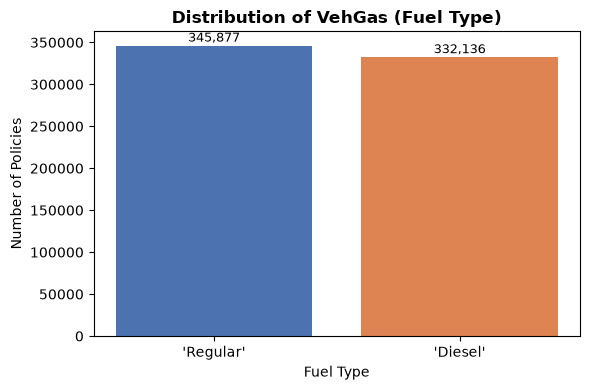

In [ ]:
print(f"[+] Unique values in VehGas: {df['VehGas'].nunique()}")  
print(df['VehGas'].unique())
print("\n[+] Value counts:")
print(df['VehGas'].value_counts())
print("\n[+] Percentage distribution:")
print(df['VehGas'].value_counts(normalize=True).round(4) * 100)

# Bar chart of VehGas distribution
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['VehGas'].value_counts()

bars = ax.bar(counts.index, counts.values, color=['#4C72B0', '#DD8452'])
ax.set_title('Distribution of VehGas (Fuel Type)', fontsize=12, fontweight='bold')
ax.set_xlabel('Fuel Type')
ax.set_ylabel('Number of Policies')

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:,}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('vehgas_distribution.png', dpi=150)
plt.show()

In [21]:
print (" ================================================== ")
print (" PEARSON MULTICOLLINEARITY AUDIT ")
print (" ================================================== ")

corr_matrix = numeric_df . corr (). abs ()

upper_tri = corr_matrix . where (np. triu (np. ones ( corr_matrix . shape ), k=1). astype ( bool ))

high_corr_pairs = []
for col in upper_tri . columns :high_corr_features = upper_tri . index [ upper_tri [col] >= 0.85]. tolist ()
for feat in high_corr_features :
    val = upper_tri .loc[feat , col]
    high_corr_pairs . append ({
        " Feature 1": feat ,
        " Feature 2": col ,
        " Pearson Correlation (|r|)": round (val , 4) ,
        " Status ": " ACTION REQUIRED : Severe Multicollinearity "
        })

if high_corr_pairs :
    display (pd. DataFrame ( high_corr_pairs ))
else :
    print ("[+] No severe collinear feature pairs (|r| >= 0.85) detected across numerical metrics .")

 PEARSON MULTICOLLINEARITY AUDIT 
[+] No severe collinear feature pairs (|r| >= 0.85) detected across numerical metrics .


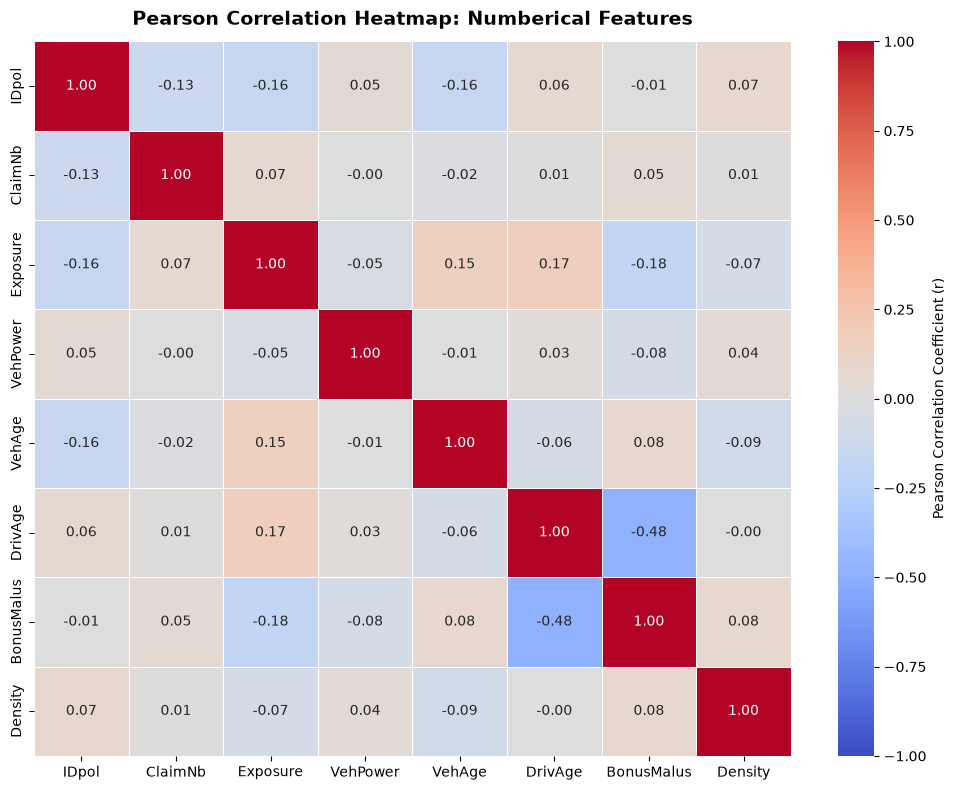

[+] Saved correlation heatmap graphics artifact to: ..\reports\figures\correlation_heatmap.png


In [31]:
# Cell 6b: Render Annotated Pearson Correlation Heatmap
plt . figure ( figsize =(10 , 8))
# Compute Pearson correlation matrix across numerical variables
corr = numeric_df . corr ()
# Generate a diverging color map (Cool - Warm : Blue = Negative , Red = Positive )
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation Coefficient (r)"}
)
plt . title("Pearson Correlation Heatmap: Numberical Features", fontsize=14, fontweight='bold', pad=12)
plt . tight_layout ()

heatmap_path = os. path . join ("..", "reports", "figures", "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.show()
print(f"[+] Saved correlation heatmap graphics artifact to: {heatmap_path}")